# AA-UTE 2026

## P7.1 - Detección de anomalías - TSB-UAD

Este practico se centra en el benchmark de detección de anomalías TSB-UAD.  

https://tsb-uad.readthedocs.io/en/latest/index.html

https://github.com/thedatumorg/TSB-UAD





In [ ]:
#TODO: Instalar previamente TSB-UAD (pip install TSB-UAD)

In [1]:
import os
import numpy as np
import pandas as pd
from TSB_UAD.utils.visualisation import plotFig
from TSB_UAD.models.iforest import IForest
from TSB_UAD.models.AE import AE_MLP2
from TSB_UAD.models.distance import Fourier
from TSB_UAD.models.lstm import lstm
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length
from TSB_UAD.vus.metrics import get_metrics
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import math

%matplotlib widget

I0000 00:00:1785310860.874357 4096546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785310860.876325 4096546 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785310860.920003 4096546 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785310862.352498 4096546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Parte 1. Pipeline de detección de anomalías

### Carga de los datos

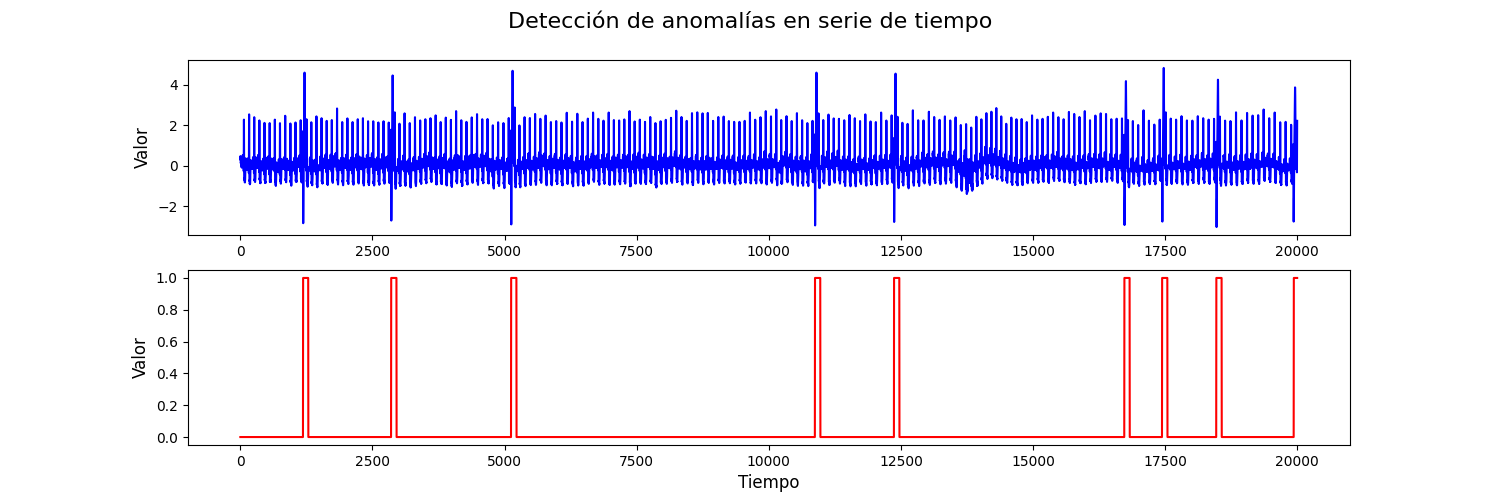

In [2]:


# Datos
filepath = 'data/benchmark/ECG/MBA_ECG805_data.out'
datos = pd.read_csv(filepath, header=None).dropna().to_numpy()
name = filepath.split('/')[-1]

# Reducir el tamaño a 20000 muestras para que no demore tanto y sea más fácil de visualizar
data = datos[:20000,0].astype(float)
label = datos[:20000,1].astype(int)


# Graficar la serie de tiempo y las anomalías
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,5))
fig.suptitle('Detección de anomalías en serie de tiempo', fontsize=16)
ax[0].plot(data, label='Serie de tiempo', color='blue')
ax[1].plot(label, color='red', label='Anomalías')
#shared x-axis 
ax[0].set_ylabel('Valor', fontsize=12)
ax[1].set_ylabel('Valor', fontsize=12)
ax[1].set_xlabel('Tiempo', fontsize=12) 
ax[1].sharex(ax[0])



### Pipeline con método Isolation Forest

AUC_ROC : 0.9838145556065632
AUC_PR : 0.7235922275868638
Precision : 0.7792207792207793
Recall : 0.7525655644241733
F : 0.765661252900232
Precision_at_k : 0.7525655644241733
Rprecision : 0.8336987403490403
Rrecall : 0.7122402436322064
RF : 0.768198227866498
R_AUC_ROC : 0.9979813464247006
R_AUC_PR : 0.9661609382518526
VUS_ROC : 0.9965137715472594
VUS_PR : 0.9149388179458927
Affiliation_Precision : 0.9836230339565581
Affiliation_Recall : 0.9975681694344366


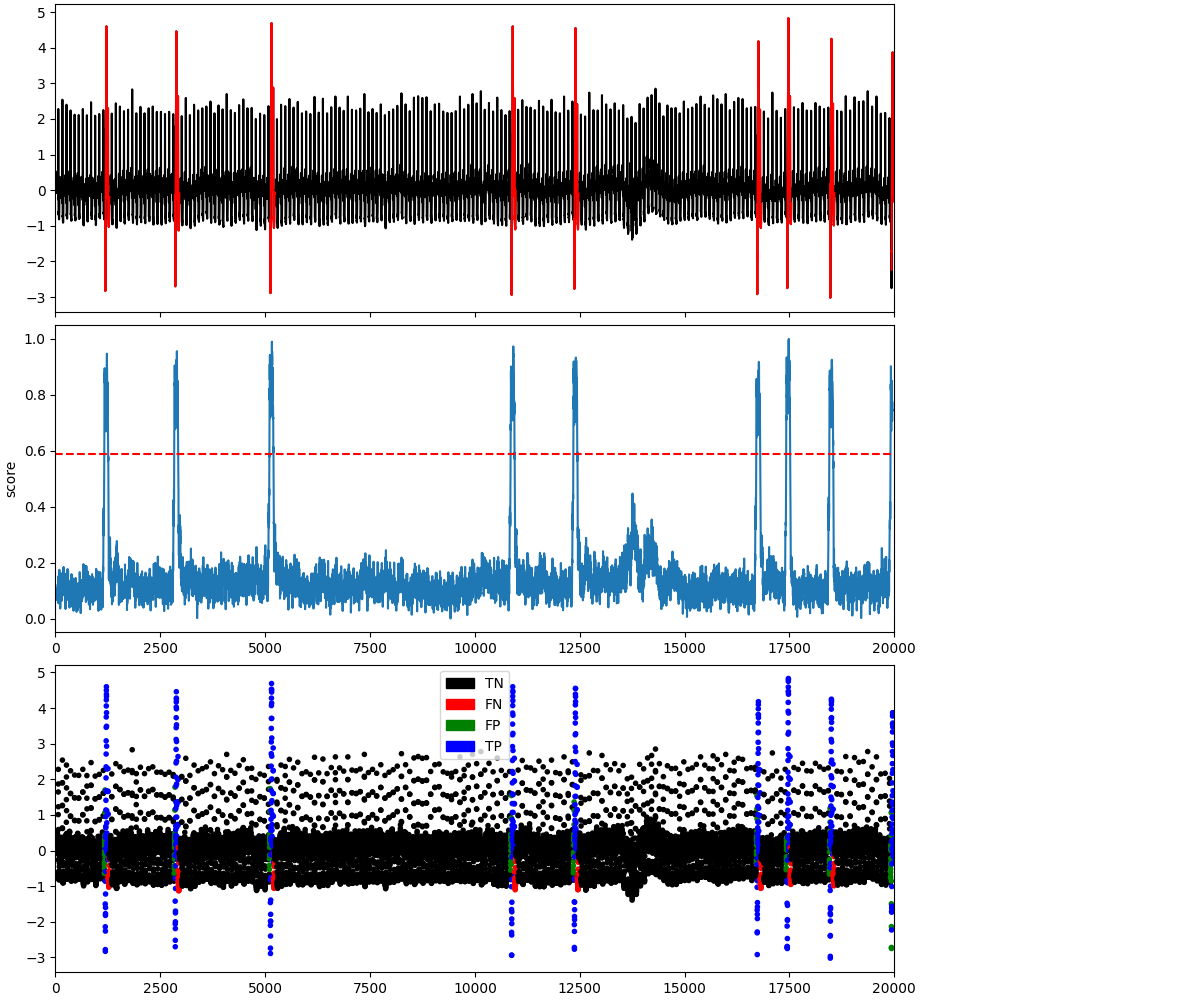

In [3]:

# 1. Pre-procesamiento ----------------------------------
# Determinar la ventana deslizante óptima 
slidingWindow = find_length(data)
# Cortar la serie de tiempo en ventanas deslizantes
X_data = Window(window = slidingWindow).convert(data).to_numpy()


# 2. Modelo ---------------------------------------------
#Run IForest
modelName='IForest'
clf = IForest(n_jobs=1)
x = X_data
clf.fit(x)

# 3. Scores ---------------------------------------------
# Disponibles luego del fit del modelo
score = clf.decision_scores_



# 4. Post-procesamiento ------------------------------------
# Escalado de los scores a un rango de 0 a 1
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
# padding de los scores para tener el mismo tamaño que la serie original
score = np.pad(score, (math.ceil((slidingWindow-1)/2), (slidingWindow-1)//2), 'edge')



# 5. Plot ---------------------------------------------

plotFig(data, label, score, slidingWindow, fileName=name, modelName=modelName) 
plt.gcf().axes[1].sharex(plt.gcf().axes[0])
plt.gcf().axes[2].sharex(plt.gcf().axes[0])


# 6. Métricas ---------------------------------------------
results = get_metrics(score, label, metric="all", slidingWindow=slidingWindow)
for metric in results.keys():
    print(metric, ':', results[metric])

### Para probar

1. ¿Cómo funciona el método sobre las series de ECG 806 y 820 ?
2. ¿Qué pasa si se asigna, a mano, otro valor a la ventana  __slidingWindow__ ?

### Para investigar

1. ¿Cómo se define el umbral (línea roja punteada en la gráfica de score)? ¿Es una buena elección? ¿Puedo usar otro criterio de umbral en TSB-UAD?
2. ¿Cómo determina la ventana óptima el método __find_length__ ?  ¿Cómo influye la ventana en la detección y en la evaluación con las métricas?
3. ¿Cómo es la relación de tamaños entre __data__ y __X_data__ ?


## Parte 2 - Pipeline con método de forecasting

### Carga de los datos

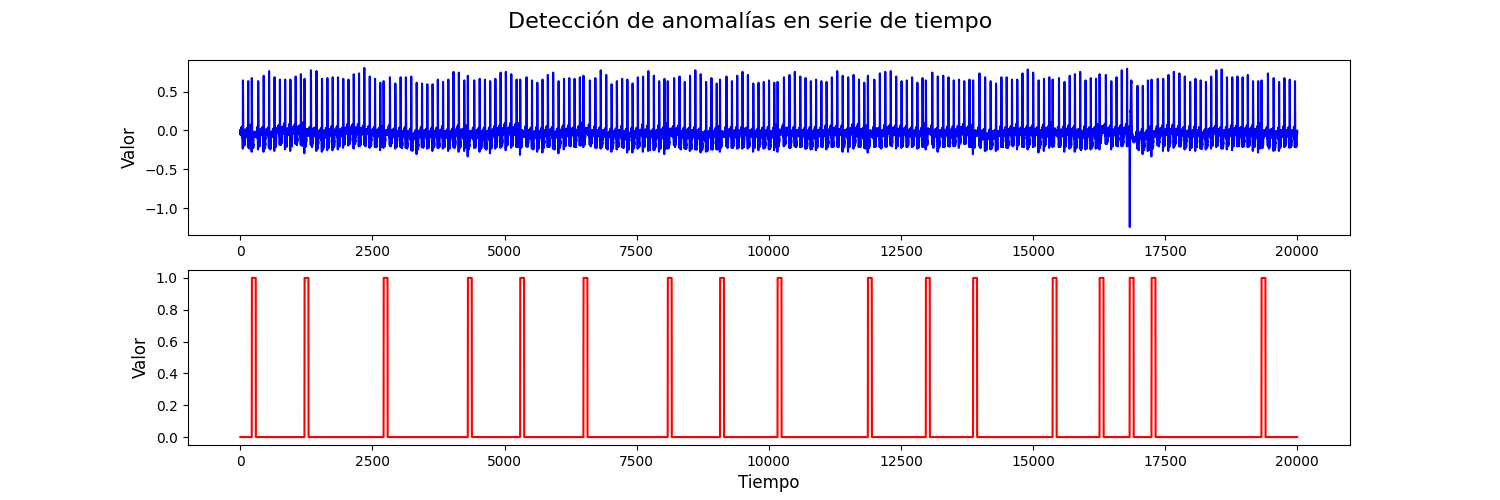

In [4]:
# Datos
filepath = 'data/benchmark/ECG/MBA_ECG820_data.out'



datos = pd.read_csv(filepath, header=None).dropna().to_numpy()
name = filepath.split('/')[-1]

# Reducir el tamaño a 20000 muestras para que no demore tanto y sea más fácil de visualizar
data = datos[:20000,0].astype(float)
label = datos[:20000,1].astype(int)


# Graficar la serie de tiempo y las anomalías
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,5))
fig.suptitle('Detección de anomalías en serie de tiempo', fontsize=16)
ax[0].plot(data, label='Serie de tiempo', color='blue')
ax[1].plot(label, color='red', label='Anomalías')
#shared x-axis 
ax[0].set_ylabel('Valor', fontsize=12)
ax[1].set_ylabel('Valor', fontsize=12)
ax[1].set_xlabel('Tiempo', fontsize=12) 
ax[1].sharex(ax[0])

E0000 00:00:1785310907.138523 4096546 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
I0000 00:00:1785310907.138556 4096546 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1785310907.138558 4096546 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: AG-ThinkPad
I0000 00:00:1785310907.138562 4096546 cuda_diagnostics.cc:183] hostname: AG-ThinkPad
I0000 00:00:1785310907.138719 4096546 cuda_diagnostics.cc:190] libcuda reported version is: 595.84.0
I0000 00:00:1785310907.138733 4096546 cuda_diagnostics.cc:194] kernel reported version is: 595.71.5
E0000 00:00:1785310907.138735 4096546 cuda_diagnostics.cc:287] kernel version 595.71.5 does not match DSO version 595.84.0 -- cannot find working devices in this configuration
/home/agomez/anaconda3/envs/time_series

622/622 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
AUC_ROC : 0.5279364171836959
AUC_PR : 0.08579960702309458
Precision : 0.11815561959654179
Recall : 0.03215686274509804
F : 0.05055487053020962
Precision_at_k : 0.03215686274509804
Rprecision : 0.04019129019129019
Rrecall : 0.07811764705882354
RF : 0.05307543276066315
R_AUC_ROC : 0.7294418351920283
R_AUC_PR : 0.2429491220405796
VUS_ROC : 0.6882162493414887
VUS_PR : 0.15243820829089866
Affiliation_Precision : 0.873112969992056
Affiliation_Recall : 0.3064829617932088


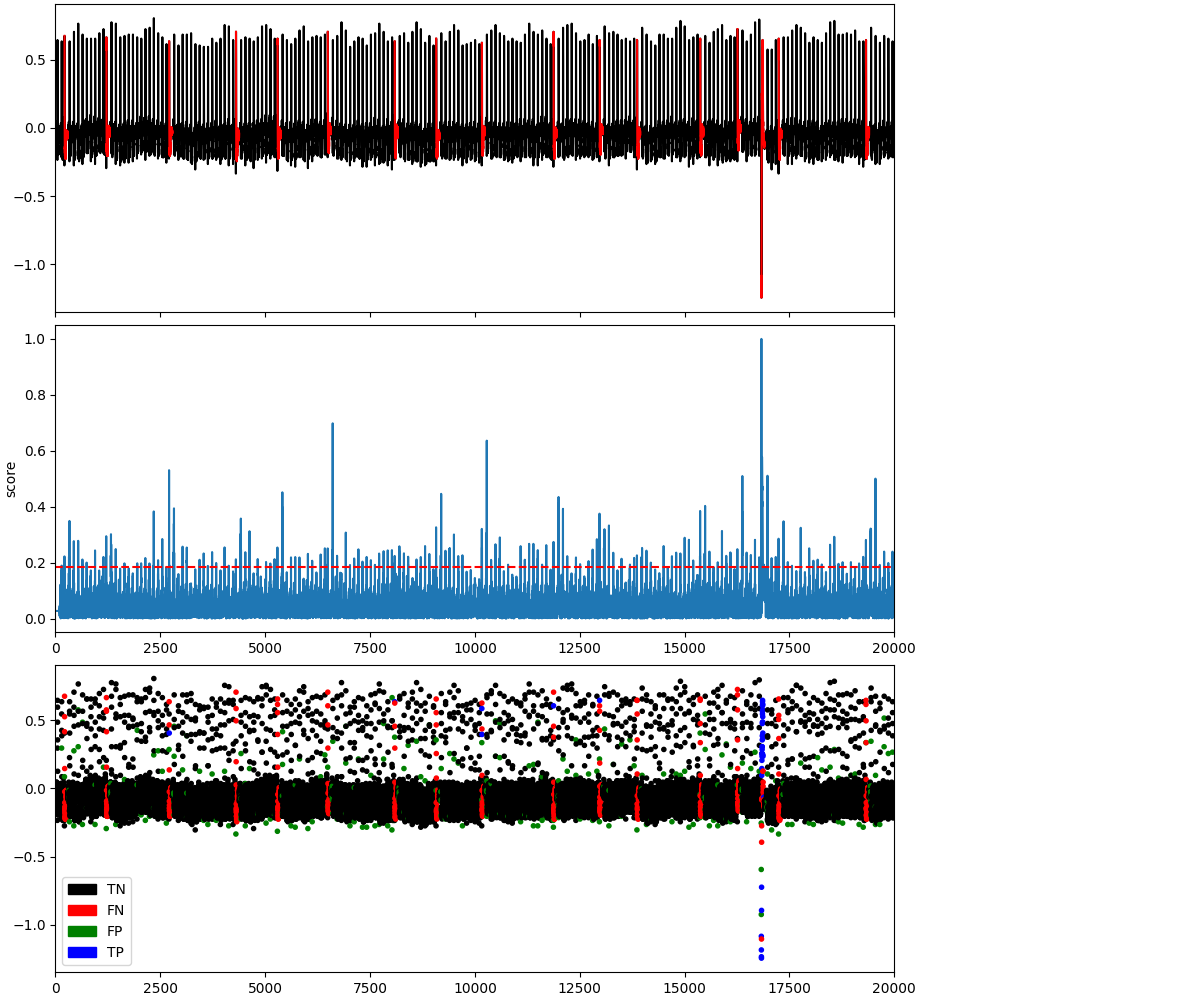

In [5]:

# 1. Pre-procesamiento ----------------------------------
# Determinar la ventana deslizante óptima 
slidingWindow = find_length(data)

# Método semi-supervisado requiere datos de entrenamiento y prueba, por lo que se separa el conjunto de datos en dos partes
data_train = data[:int(0.1*len(data))]
data_test = data

    
# 2. Modelo ---------------------------------------------
#Run AE
modelName='AE'
modelName='LSTM'
clf = lstm(slidingwindow = slidingWindow, predict_time_steps=1, epochs = 50, patience = 5, verbose=0)
clf.fit(data_train, data_test)
measure = Fourier()
measure.detector = clf
measure.set_param()
clf.decision_function(measure=measure)

# 3. Scores ---------------------------------------------
# Disponibles luego del fit del modelo
score = clf.decision_scores_



# 4. Post-procesamiento ------------------------------------
# Escalado de los scores a un rango de 0 a 1
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()

# # padding de los scores para tener el mismo tamaño que la serie original
# score = np.pad(score, (math.ceil((slidingWindow-1)/2), (slidingWindow-1)//2), 'edge')



# 5. Plot ---------------------------------------------

plotFig(data, label, score, slidingWindow, fileName=name, modelName=modelName) 

plt.gcf().axes[1].sharex(plt.gcf().axes[0])
plt.gcf().axes[2].sharex(plt.gcf().axes[0])

# 6. Métricas ---------------------------------------------
results = get_metrics(score, label, metric="all", slidingWindow=slidingWindow)
for metric in results.keys():
    print(metric, ':', results[metric])

## Parte 2 - Pipeline con método de reconstrucción

### Carga de los datos

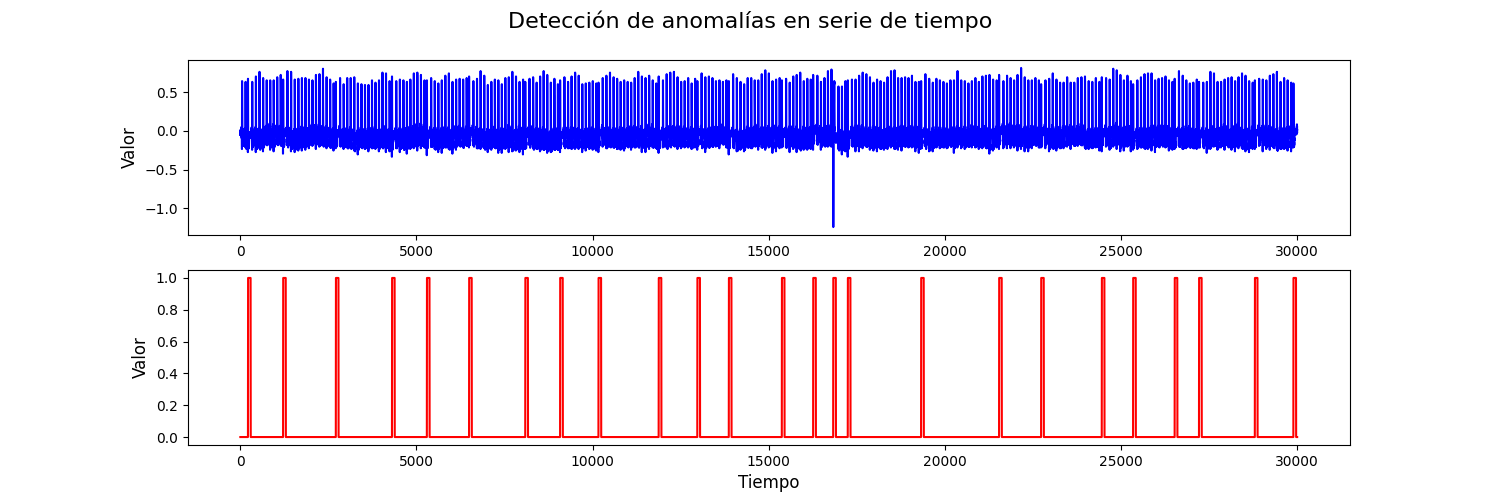

In [6]:
# Datos
filepath = 'data/benchmark/ECG/MBA_ECG820_data.out'



datos = pd.read_csv(filepath, header=None).dropna().to_numpy()
name = filepath.split('/')[-1]

# Reducir el tamaño a 20000 muestras para que no demore tanto y sea más fácil de visualizar
data = datos[:30000,0].astype(float)
label = datos[:30000,1].astype(int)


# Graficar la serie de tiempo y las anomalías
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,5))
fig.suptitle('Detección de anomalías en serie de tiempo', fontsize=16)
ax[0].plot(data, label='Serie de tiempo', color='blue')
ax[1].plot(label, color='red', label='Anomalías')
#shared x-axis 
ax[0].set_ylabel('Valor', fontsize=12)
ax[1].set_ylabel('Valor', fontsize=12)
ax[1].set_xlabel('Tiempo', fontsize=12) 
ax[1].sharex(ax[0])

935/935 ━━━━━━━━━━━━━━━━━━━━ 1s 494us/step
AUC_ROC : 0.8533361872592593
AUC_PR : 0.3130613465197427
Precision : 0.44976816074188564
Recall : 0.1552
F : 0.23076923076923078
Precision_at_k : 0.1552
Rprecision : 0.35694235588972434
Rrecall : 0.2951466666666666
RF : 0.32311645462146615
R_AUC_ROC : 0.9822687790868574
R_AUC_PR : 0.8236402465289425
VUS_ROC : 0.953983364794746
VUS_PR : 0.5903603039294711
Affiliation_Precision : 0.878660062751366
Affiliation_Recall : 0.2565118632831426


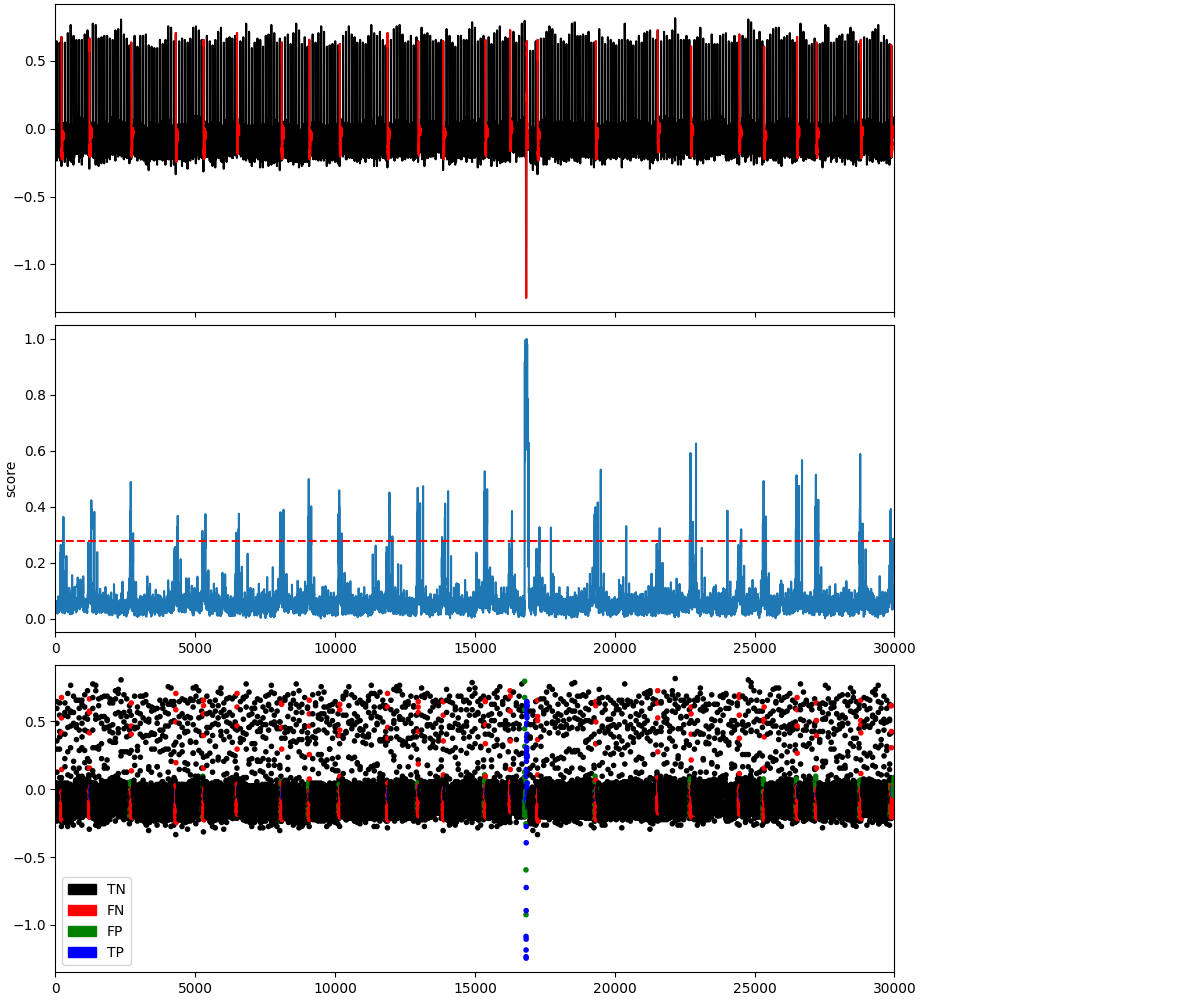

In [7]:

# 1. Pre-procesamiento ----------------------------------
# Determinar la ventana deslizante óptima 
slidingWindow = find_length(data)

# Método semi-supervisado requiere datos de entrenamiento y prueba, por lo que se separa el conjunto de datos en dos partes
data_train = data[:int(0.1*len(data))]
data_test = data

    
# 2. Modelo ---------------------------------------------
#Run AE
modelName='AE'
clf = AE_MLP2(slidingWindow = slidingWindow, epochs=100, verbose=0)
clf.fit(data_train, data_test)

# 3. Scores ---------------------------------------------
# Disponibles luego del fit del modelo
score = clf.decision_scores_



# 4. Post-procesamiento ------------------------------------
# Escalado de los scores a un rango de 0 a 1
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()

# # padding de los scores para tener el mismo tamaño que la serie original
# score = np.pad(score, (math.ceil((slidingWindow-1)/2), (slidingWindow-1)//2), 'edge')



# 5. Plot ---------------------------------------------

plotFig(data, label, score, slidingWindow, fileName=name, modelName=modelName) 

plt.gcf().axes[1].sharex(plt.gcf().axes[0])
plt.gcf().axes[2].sharex(plt.gcf().axes[0])

# 6. Métricas ---------------------------------------------
results = get_metrics(score, label, metric="all", slidingWindow=slidingWindow)
for metric in results.keys():
    print(metric, ':', results[metric])